In [1]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [3]:
iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']].values 
y = (iris.target ==2)


In [4]:
X 

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

In [5]:
svm_clf = make_pipeline(StandardScaler(),LinearSVC(C = 1, random_state=42))
svm_clf.fit(X, y)

,steps,"[('standardscaler', ...), ('linearsvc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


In [9]:
X_new = [[5.5, 2], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [10]:
svm_clf.decision_function(X_new)

array([ 1.3358159 , -0.22035761])

In [23]:
from sklearn.datasets import make_moons 
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise = 0.15, random_state=42)
polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C= 10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

,steps,"[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [12]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(), SVC(kernel = 'poly', degree = 3, coef0=1, C = 5 ))
poly_kernel_svm_clf.fit(X, y)

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,5
,kernel,'poly'
,degree,3
,gamma,'scale'


In [25]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values 
y = iris.target 

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

C = 5 
alpha = 0.05

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
linear_svc = LinearSVC(loss = 'hinge', dual= True, random_state=42, C = C).fit(X_scaled, y)
svc = SVC(kernel='linear').fit(X_scaled, y)
sgdclassifier = SGDClassifier(alpha=alpha, random_state = 42).fit(X_scaled, y)


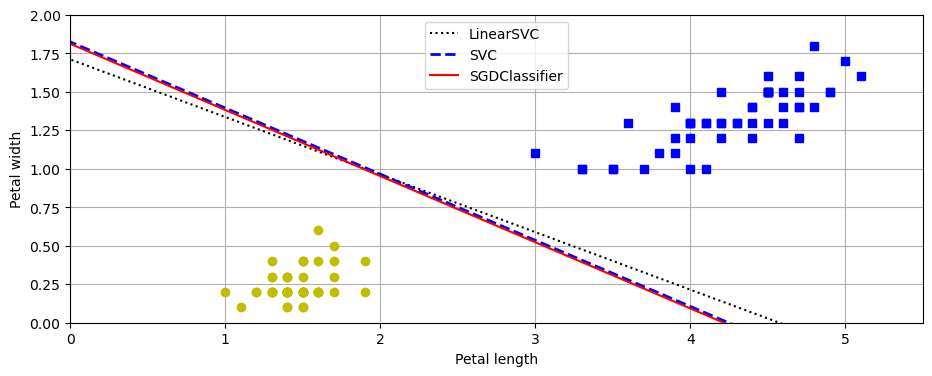

In [11]:
import matplotlib.pyplot as plt
def compute_decision_boundary(model):
    w = -model.coef_[0, 0] / model.coef_[0, 1]
    b = -model.intercept_[0] / model.coef_[0, 1]
    return scaler.inverse_transform([[-10, -10 * w + b], [10, 10 * w + b]])

lin_line = compute_decision_boundary(linear_svc)
svc_line = compute_decision_boundary(svc)
sgd_line = compute_decision_boundary(sgdclassifier)

# Plot all three decision boundaries
plt.figure(figsize=(11, 4))
plt.plot(lin_line[:, 0], lin_line[:, 1], "k:", label="LinearSVC")
plt.plot(svc_line[:, 0], svc_line[:, 1], "b--", linewidth=2, label="SVC")
plt.plot(sgd_line[:, 0], sgd_line[:, 1], "r-", label="SGDClassifier")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs") # label="Iris versicolor"
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo") # label="Iris setosa"
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper center")
plt.axis([0, 5.5, 0, 2])
plt.grid()

plt.show()

# Independent exploration with the wine and california housing datasets 

In [96]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame= True)
list(wine)

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names']

In [97]:
wine.data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [98]:
wine.target.value_counts()

1    71
0    59
2    48
Name: target, dtype: int64

In [99]:
X = wine.data.values
y = wine.target 

In [100]:
X_scaled = scaler.fit_transform(X)

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.2)

In [102]:
zero_data = (y_train == 0).astype(int) 
one_data = (y_train ==1).astype(int)
two_data = (y_train ==2).astype(int)
C = 1
alpha = 0.05
scaler = StandardScaler()
zero_svm = LinearSVC( dual= True).fit(X_train, zero_data)
one_svm = LinearSVC( dual= True).fit(X_train, one_data)
two_svm = LinearSVC( dual= True).fit(X_train, two_data)


/Users/hendy/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/hendy/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/hendy/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [103]:
import numpy as np 
zero_score = zero_svm.decision_function(X_test)
one_score = one_svm.decision_function(X_test)
two_score = two_svm.decision_function(X_test)

scores = np.column_stack([zero_score, one_score, two_score])
# a higher score means the sample is more confidently assigned to the positive class.
predicted_class = np.argmax(scores, axis = 1)
(predicted_class == y_test).mean()



0.75

In [104]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

linear_svm = make_pipeline(StandardScaler(), LinearSVC(C = C))
cross_val_score(linear_svm, X_train, y_train).mean()

0.9859605911330049

In [105]:
svm = make_pipeline(StandardScaler(), SVC())
cross_val_score(svm, X_train, y_train).mean()


0.9928571428571429

In [106]:
svm.fit(X_train, y_train)
(svm.predict(X_test) == y_test).mean()

0.9444444444444444

In [1]:
!python --version

Python 3.11.4


In [29]:
from sklearn.datasets import fetch_california_housing

data =fetch_california_housing(as_frame= True)
df = data.data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

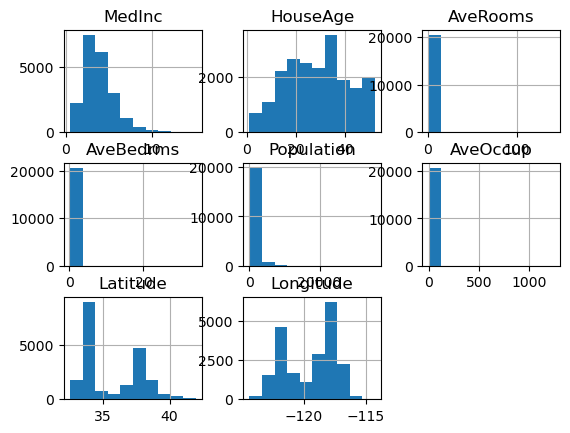

In [30]:
df.hist()

In [31]:
from sklearn.svm import LinearSVR, SVR
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

In [32]:
X = data.data 
y = data.target 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [34]:
linear_svr = LinearSVR(dual = True, random_state=42)
linear_svr.fit(X_train, y_train)
y_predict = linear_svr.predict(X_test)

/Users/hendy/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [35]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, y_predict)

0.764402819345366

In [13]:
svr = SVR(kernel='poly').fit(X_train, y_train)
root_mean_squared_error(y_test, svr.predict(X_test))

10.667414261797783

In [ ]:
sgd = SGDRegressor( ).fit(X_train, y_train)
root_mean_squared_error(y_test, sgd.predict(X_test))


36.27436953874866

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

svr = SVR()
param_distribs = {'gamma': loguniform(0.001, 0.1), 'C': uniform(1, 10)}
rnd_search = RandomizedSearchCV(svr, param_distribs, n_iter=100, cv =3, random_state=42)
rnd_search.fit(X_train[:2000], y_train[:2000])


,estimator,SVR()
,param_distributions,"{'C': <scipy.stats....t 0x1376fd5d0>, 'gamma': <scipy.stats....t 0x15ff97490>}"
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
from sklearn.model_selection import cross_val_score
-cross_val_score(rnd_search.best_estimator_, X_train, y_train, scoring = 'neg_root_mean_squared_error')

array([0.58738961, 0.58294641, 0.60083047, 0.57346169, 0.6013401 ])

In [43]:
root_mean_squared_error(y_test, rnd_search.best_estimator_.predict(X_test))

0.6202355439126965

In [44]:
rnd_search.best_estimator_

,kernel,'rbf'
,degree,3
,gamma,0.06161049539380964
,coef0,0.0
,tol,0.001
,C,10.394989415641891
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1
